<a href="https://colab.research.google.com/github/too-baa/hospital-readmission-prediction/blob/main/CaseStudy1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Importing and Studying Data

In [ ]:
import pandas as pd

# Loads the dataset straight from the web into a DataFrame
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
train = pd.read_csv(url, header=None)

In [ ]:
print(train.shape)

(768, 9)


In [ ]:
print(train.head())

   0    1   2   3    4     5      6   7  8
0  6  148  72  35    0  33.6  0.627  50  1
1  1   85  66  29    0  26.6  0.351  31  0
2  8  183  64   0    0  23.3  0.672  32  1
3  1   89  66  23   94  28.1  0.167  21  0
4  0  137  40  35  168  43.1  2.288  33  1


In [ ]:
print(train.info())
print(train.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None
                0           1           2           3           4           5  \
count  768.000000  768.000000  768.000000  768.000000  768.000000  768.000000   
mean     3.845052  120.894531   69.105469   20.536458   79.799479   31.992578   
std      3.369578   31.972618   19.355807   15.952218  115.244002    7.884160   
min      0.000000    0.000000    0.000000    0.000000    0.000000    0.000000   
25%      1.000000   99.00000

In [ ]:
train.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0


In [ ]:
train.duplicated().sum()

np.int64(0)

2. EDA and Visualisation

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

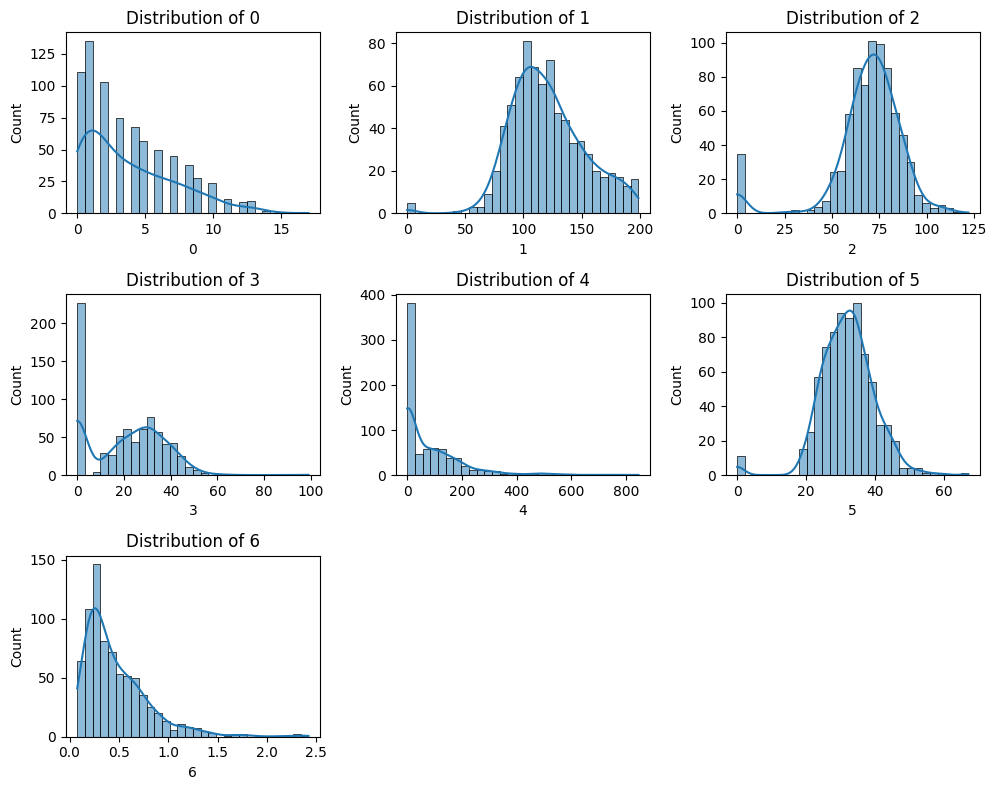

In [ ]:
plt.figure(figsize=(10,8))
for i, col in enumerate(train.columns[0:7]):
  plt.subplot(3,3,i+1)
  sns.histplot(train[col], kde=True, bins=30)
  plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

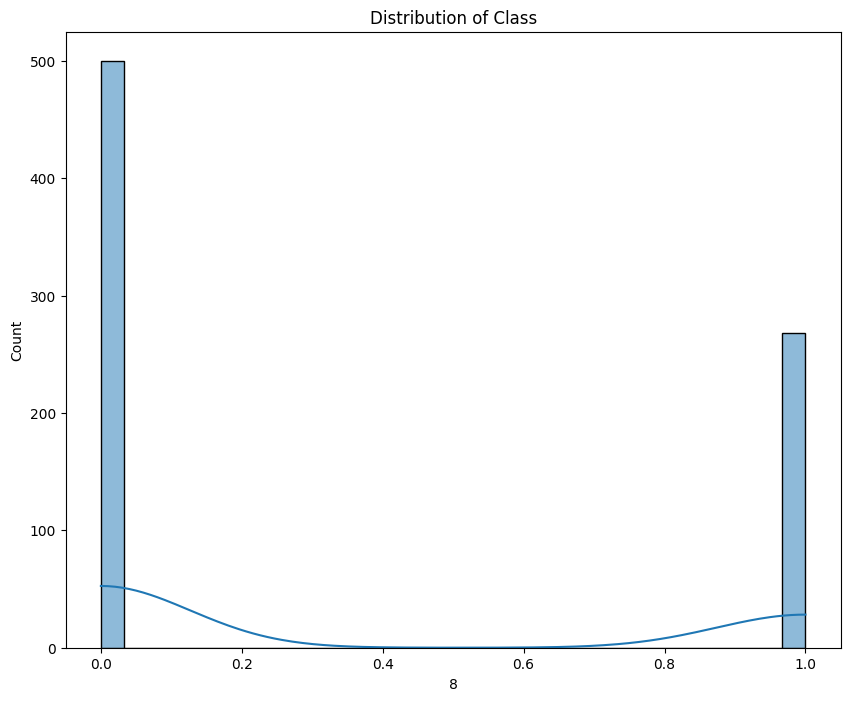

In [ ]:
plt.figure(figsize=(10,8))
sns.histplot(train[8], kde=True, bins=30)
plt.title("Distribution of Class")
plt.show()

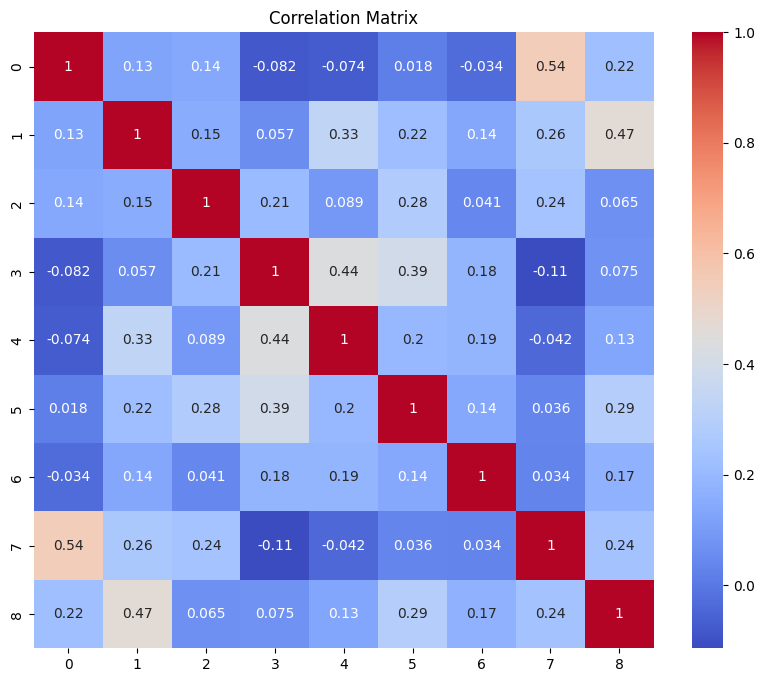

In [ ]:
#correlation heatmap
plt.figure(figsize=(10,8))
corr=train.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

3. Splitting and Scaling

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X = train.drop(columns=[8])
y = train[8]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

4. Training and Evaluating Model

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, confusion_matrix

In [ ]:
model=LogisticRegression(penalty='l2', C=0.2)
model.fit(X_train_scaled,y_train)
y_pred=model.predict(X_test_scaled)

roc_auc=roc_auc_score(y_test, y_pred)
print("ROC_AUC_SCORE: ", roc_auc)
print("Confusion Matrix: \n", confusion_matrix(y_test, y_pred))

ROC_AUC_SCORE:  0.7404040404040404
Confusion Matrix: 
 [[80 19]
 [18 37]]
